In [1]:
import numpy as np
import math 
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot
from numpy import sqrt, cos, exp, sin, pi

In [98]:
def g(t,tau):
    return -t/tau+1

def u(q,ga):
    bq= sin(q)
    aq= ga + cos(q)
    omega_q= sqrt(ga*ga+2*ga*cos(q)+1)

    return (aq-omega_q)/np.sqrt(2*omega_q*(omega_q-aq))



def v(q,ga):
    bq= sin(q)
    aq= ga+ cos(q)
    omega_q= sqrt(ga*ga+2*ga*cos(q)+1)

    return (bq)/np.sqrt(2*omega_q*(omega_q-aq))




from mpmath import pcfd

def u_tilde(tau,q,t):
    bq= sin(q)
    aq= 1+ cos(q)
    #Rotation
    theta = exp(-1j* 3*pi/4)
    #Prefactor
    prefactor = theta* bq * sqrt(tau) *exp(-pi*bq*bq*tau/4)
    #Nu
    nu = 1j*bq*bq*tau-1
    #Argument
    argument = 2*(t-aq*tau)/sqrt(tau)/theta
    #Compute
    return complex(prefactor* pcfd(nu,argument))


def v_tilde(tau,q,t):
    bq= sin(q)
    aq= 1+ cos(q)
    #Rotation
    theta = exp(-1j* 3*pi/4)
    #Prefactor
    prefactor = -exp(-pi*bq*bq*tau/4)
    #Nu
    nu = 1j*bq*bq*tau



    #Argument
    argument = 2*(t-aq*tau)/sqrt(tau)/theta
    #Compute
    return complex(prefactor* pcfd(nu,argument))

g(t,tau)

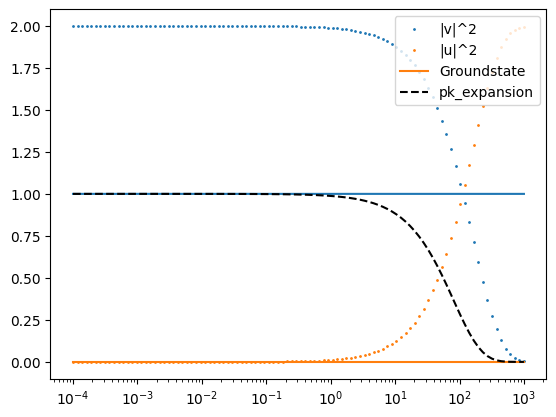

In [99]:
q = pi/100

qv= np.linspace(0,pi,200)
tauv = np.logspace(-4,3,100)



plt.scatter(tauv,[2*np.abs(v_tilde(tau,q,tau*10000))**2 for tau in tauv],label="|v|^2",s=1)
plt.scatter(tauv,[2*np.abs(u_tilde(tau,q,tau*10000))**2 for tau in tauv],label="|u|^2",s=1)
plt.plot(tauv,[np.abs(u_tilde(tau,q,tau*10000))**2 + np.abs(v_tilde(tau,q,tau*10000)**2) for tau in tauv])

plot(tauv,[2*np.abs(v(q,g(tau*10000,tau)))**2 for tau in tauv],label="Groundstate")
plt.plot(tauv,[exp(-2*pi*sin(q)*sin(q)*tau)**2 for tau in tauv],label="pk_expansion",color="black",linestyle="--")
plt.xscale("log")

plt.legend()


In [100]:
from mpmath import mp, pcfd

mp.dps = 50        # increase precision
mp.maxterms = 1000000000000 # increase allowed max terms


In [101]:
qv = np.linspace(0, np.pi, 100)  # assuming qv is defined
tauv = np.logspace(-2,3,20)  # or a range of tau values

dat = []
for tau in tauv:
    x = np.array([
        (
            1 +
            np.cos(q) * (np.abs(u_tilde(tau, q, tau))**2 - np.abs(v_tilde(tau, q, tau))**2)
            - 1j * np.sin(q) * (
                u_tilde(tau, q, tau) * np.conj(v_tilde(tau, q, tau))
                - np.conj(u_tilde(tau, q, tau)) * v_tilde(tau, q, tau)
            )
        ) / 2
        for q in qv
    ])
    dat.append(np.mean(x))
dat

KeyboardInterrupt: 

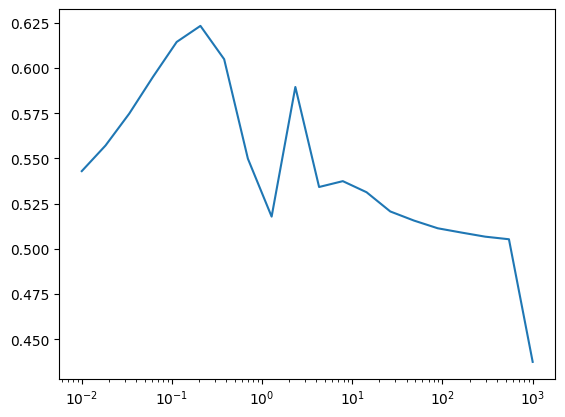

In [401]:
plot(tauv,dat)
plt.xscale("log")

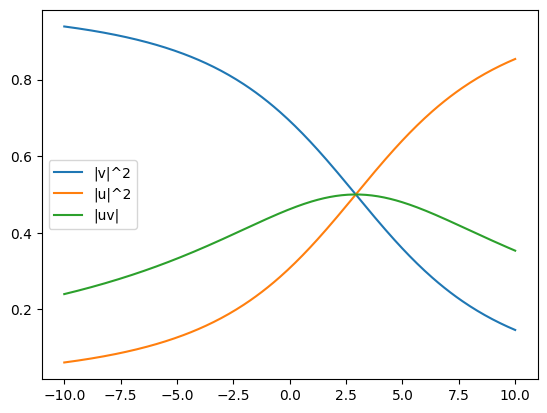

In [102]:
tau = 10
q = 3*pi/4
t = 15
#plt.xscale("log")
qv= np.linspace(0,pi,100)
tv = np.linspace(-10,10,300)
tauv = np.logspace(-3,3,100)

plot(tv,[np.abs(v_tilde(tau,q,t)**2) for t in tv],label="|v|^2")

plot(tv,[np.abs(u_tilde(tau,q,t)**2) for t in tv],label="|u|^2")
plot(tv,[np.abs(u_tilde(tau,q,t)*v_tilde(tau,q,t)) for t in tv],label="|uv|")

plt.legend()


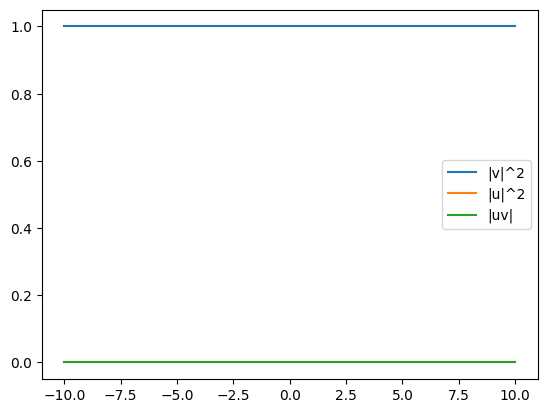

In [103]:
tau = 10
q = pi
t = 15

qv= np.linspace(0,pi,100)
tv = np.linspace(-10,10,300)
tauv = np.logspace(-3,3,100)

plot(tv,[np.abs(v_tilde(tau,q,t)**2) for t in tv],label="|v|^2")

plot(tv,[np.abs(u_tilde(tau,q,t)**2) for t in tv],label="|u|^2")
plot(tv,[np.abs(u_tilde(tau,q,t)*v_tilde(tau,q,t)) for t in tv],label="|uv|")

plt.legend()


In [206]:
def R(q,g):

    a= u(q,g)
    b= -1j*v(q,g)
    return np.array([[a,b],[b,a]])

def S(q,t,tau):
    a = complex(u_tilde(tau,q,t))
    b = complex(v_tilde(tau,q,t))

    return np.array([[a,-np.conj(b)],[b,np.conj(a)]])

tau = .05
q = pi/8
print(S(q,t,tau))
print(R(q,g(t,tau)))
tauv = np.logspace(-2,3,50)

tv = np.linspace(-2*tau,100*tau,100)
print(g(tau,tau))
x= []
for t in tv:
    Sa = S(q,t,tau)
    Ra = R(q,g(t,tau))
    s3 = np.array([[1, 0],[0,-1]])

    x+= [(Sa.T.conj()@Ra.T.conj()@s3@Ra@Sa)[1,1]+1]

[[-0.07828682-0.07539703j  0.99406524+0.00455601j]
 [-0.99406524+0.00455601j -0.07828682+0.07539703j]]
[[-0.77301045+0.j          0.        -0.63439328j]
 [ 0.        -0.63439328j -0.77301045+0.j        ]]
0.0


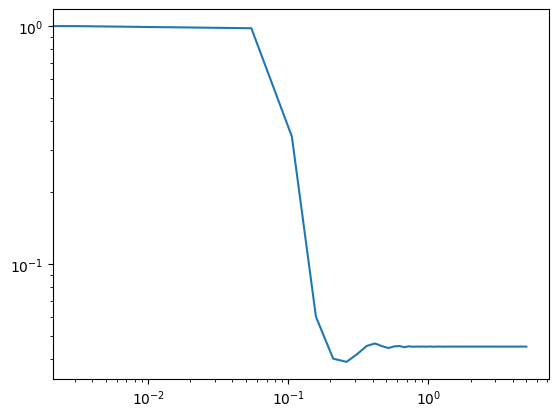

In [211]:
plot(tv,1-np.array(x)/2)
#plot(tauv,tauv**(-3/2))
#plt.plot(tauv,[exp(-2*pi*sin(q)*sin(q)*tau) for tau in tauv],label="pk_expansion",color="black",linestyle="--")
plt.xscale("log")
plt.yscale("log")